# Exploratory Data Analysis — E-Commerce Customer Churn

This notebook performs a comprehensive EDA on the E-Commerce Customer Churn dataset to understand patterns, identify data quality issues, and inform the cleaning and feature engineering steps.

**Dataset:** 5,630 customers × 20 features | **Target:** Churn (binary)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100

## 1. Load Dataset

In [2]:
df = pd.read_excel("../data/raw/E Commerce Dataset.xlsx", sheet_name="E Comm")
print(f"Shape: {df.shape}")
df.head()

Shape: (5630, 20)


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,5630.0,NaN,NaN,NaN,52815.5,1625.385339,50001.0,51408.25,52815.5,54222.75,55630.0
Churn,5630.0,NaN,NaN,NaN,0.168384,0.37424,0.0,0.0,0.0,0.0,1.0
Tenure,5366.0,NaN,NaN,NaN,10.189899,8.557241,0.0,2.0,9.0,16.0,61.0
PreferredLoginDevice,5630,3,Mobile Phone,2765,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CityTier,5630.0,NaN,NaN,NaN,1.654707,0.915389,1.0,1.0,1.0,3.0,3.0
WarehouseToHome,5379.0,NaN,NaN,NaN,15.639896,8.531475,5.0,9.0,14.0,20.0,127.0
PreferredPaymentMode,5630,7,Debit Card,2314,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,5630,2,Male,3384,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HourSpendOnApp,5375.0,NaN,NaN,NaN,2.931535,0.721926,0.0,2.0,3.0,3.0,5.0
NumberOfDeviceRegistered,5630.0,NaN,NaN,NaN,3.688988,1.023999,1.0,3.0,4.0,4.0,6.0


## 2. Missing Values Analysis

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Count": missing, "Percentage": missing_pct})
missing_df = missing_df[missing_df["Count"] > 0].sort_values("Percentage", ascending=False)
print(f"Total missing cells: {missing.sum()} out of {df.size} ({missing.sum()/df.size*100:.2f}%)")
missing_df

Total missing cells: 1856 out of 112600 (1.65%)


,Count,Percentage
DaySinceLastOrder,307,5.45
OrderAmountHikeFromlastYear,265,4.71
Tenure,264,4.69
OrderCount,258,4.58
CouponUsed,256,4.55
HourSpendOnApp,255,4.53
WarehouseToHome,251,4.46


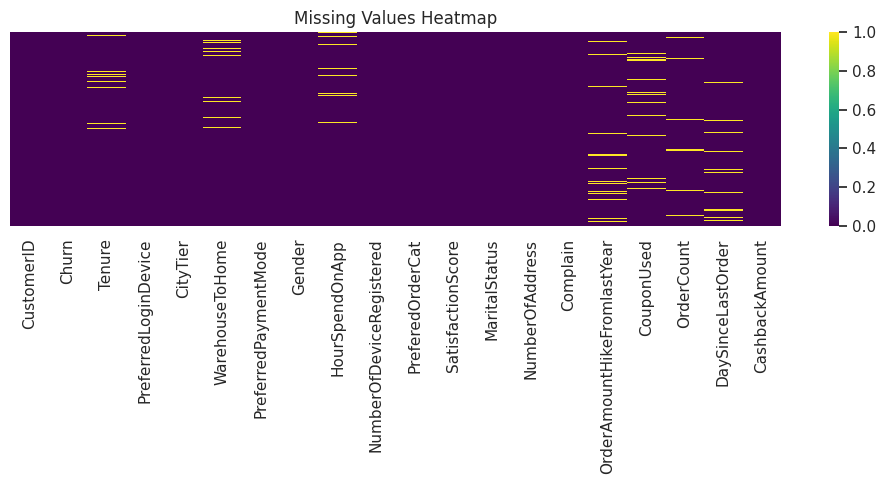

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap="viridis", ax=ax)
ax.set_title("Missing Values Heatmap")
plt.tight_layout()
plt.show()

## 3. Duplicates Check

In [7]:
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Duplicate CustomerIDs: {df['CustomerID'].duplicated().sum()}")

Duplicate rows: 0
Duplicate CustomerIDs: 0


### Duplicate Categories in Categorical Columns

In [8]:
cat_cols = df.select_dtypes(include="object").columns.tolist()
for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())


PreferredLoginDevice:
PreferredLoginDevice
Mobile Phone    2765
Computer        1634
Phone           1231
Name: count, dtype: int64

PreferredPaymentMode:
PreferredPaymentMode
Debit Card          2314
Credit Card         1501
E wallet             614
UPI                  414
COD                  365
CC                   273
Cash on Delivery     149
Name: count, dtype: int64

Gender:
Gender
Male      3384
Female    2246
Name: count, dtype: int64

PreferedOrderCat:
PreferedOrderCat
Laptop & Accessory    2050
Mobile Phone          1271
Fashion                826
Mobile                 809
Grocery                410
Others                 264
Name: count, dtype: int64

MaritalStatus:
MaritalStatus
Married     2986
Single      1796
Divorced     848
Name: count, dtype: int64


**Duplicate categories found:**
- `PreferredLoginDevice`: "Phone" and "Mobile Phone" are the same
- `PreferredPaymentMode`: "CC" = "Credit Card", "COD" = "Cash on Delivery"
- `PreferedOrderCat`: "Mobile" and "Mobile Phone" are the same

## 4. Target Variable — Churn Distribution

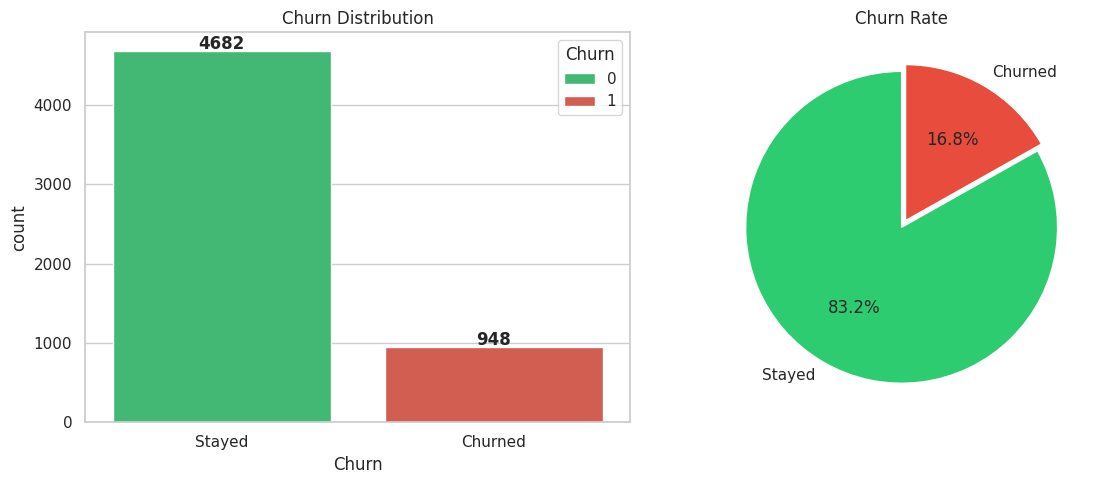

Churn rate: 16.84%


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
churn_counts = df["Churn"].value_counts()
sns.countplot(x="Churn", data=df, ax=axes[0], hue="Churn", palette=["#2ecc71", "#e74c3c"])
axes[0].set_title("Churn Distribution")
axes[0].set_xticklabels(["Stayed", "Churned"])
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 30, str(v), ha="center", fontweight="bold")

# Pie chart
axes[1].pie(churn_counts.values, labels=["Stayed", "Churned"], autopct="%1.1f%%",
            colors=["#2ecc71", "#e74c3c"], startangle=90, explode=(0, 0.05))
axes[1].set_title("Churn Rate")

plt.tight_layout()
plt.show()

print(f"Churn rate: {df['Churn'].mean()*100:.2f}%")

## 5. Univariate Analysis

### 5.1 Numeric Features — Distributions

Numeric features: 13


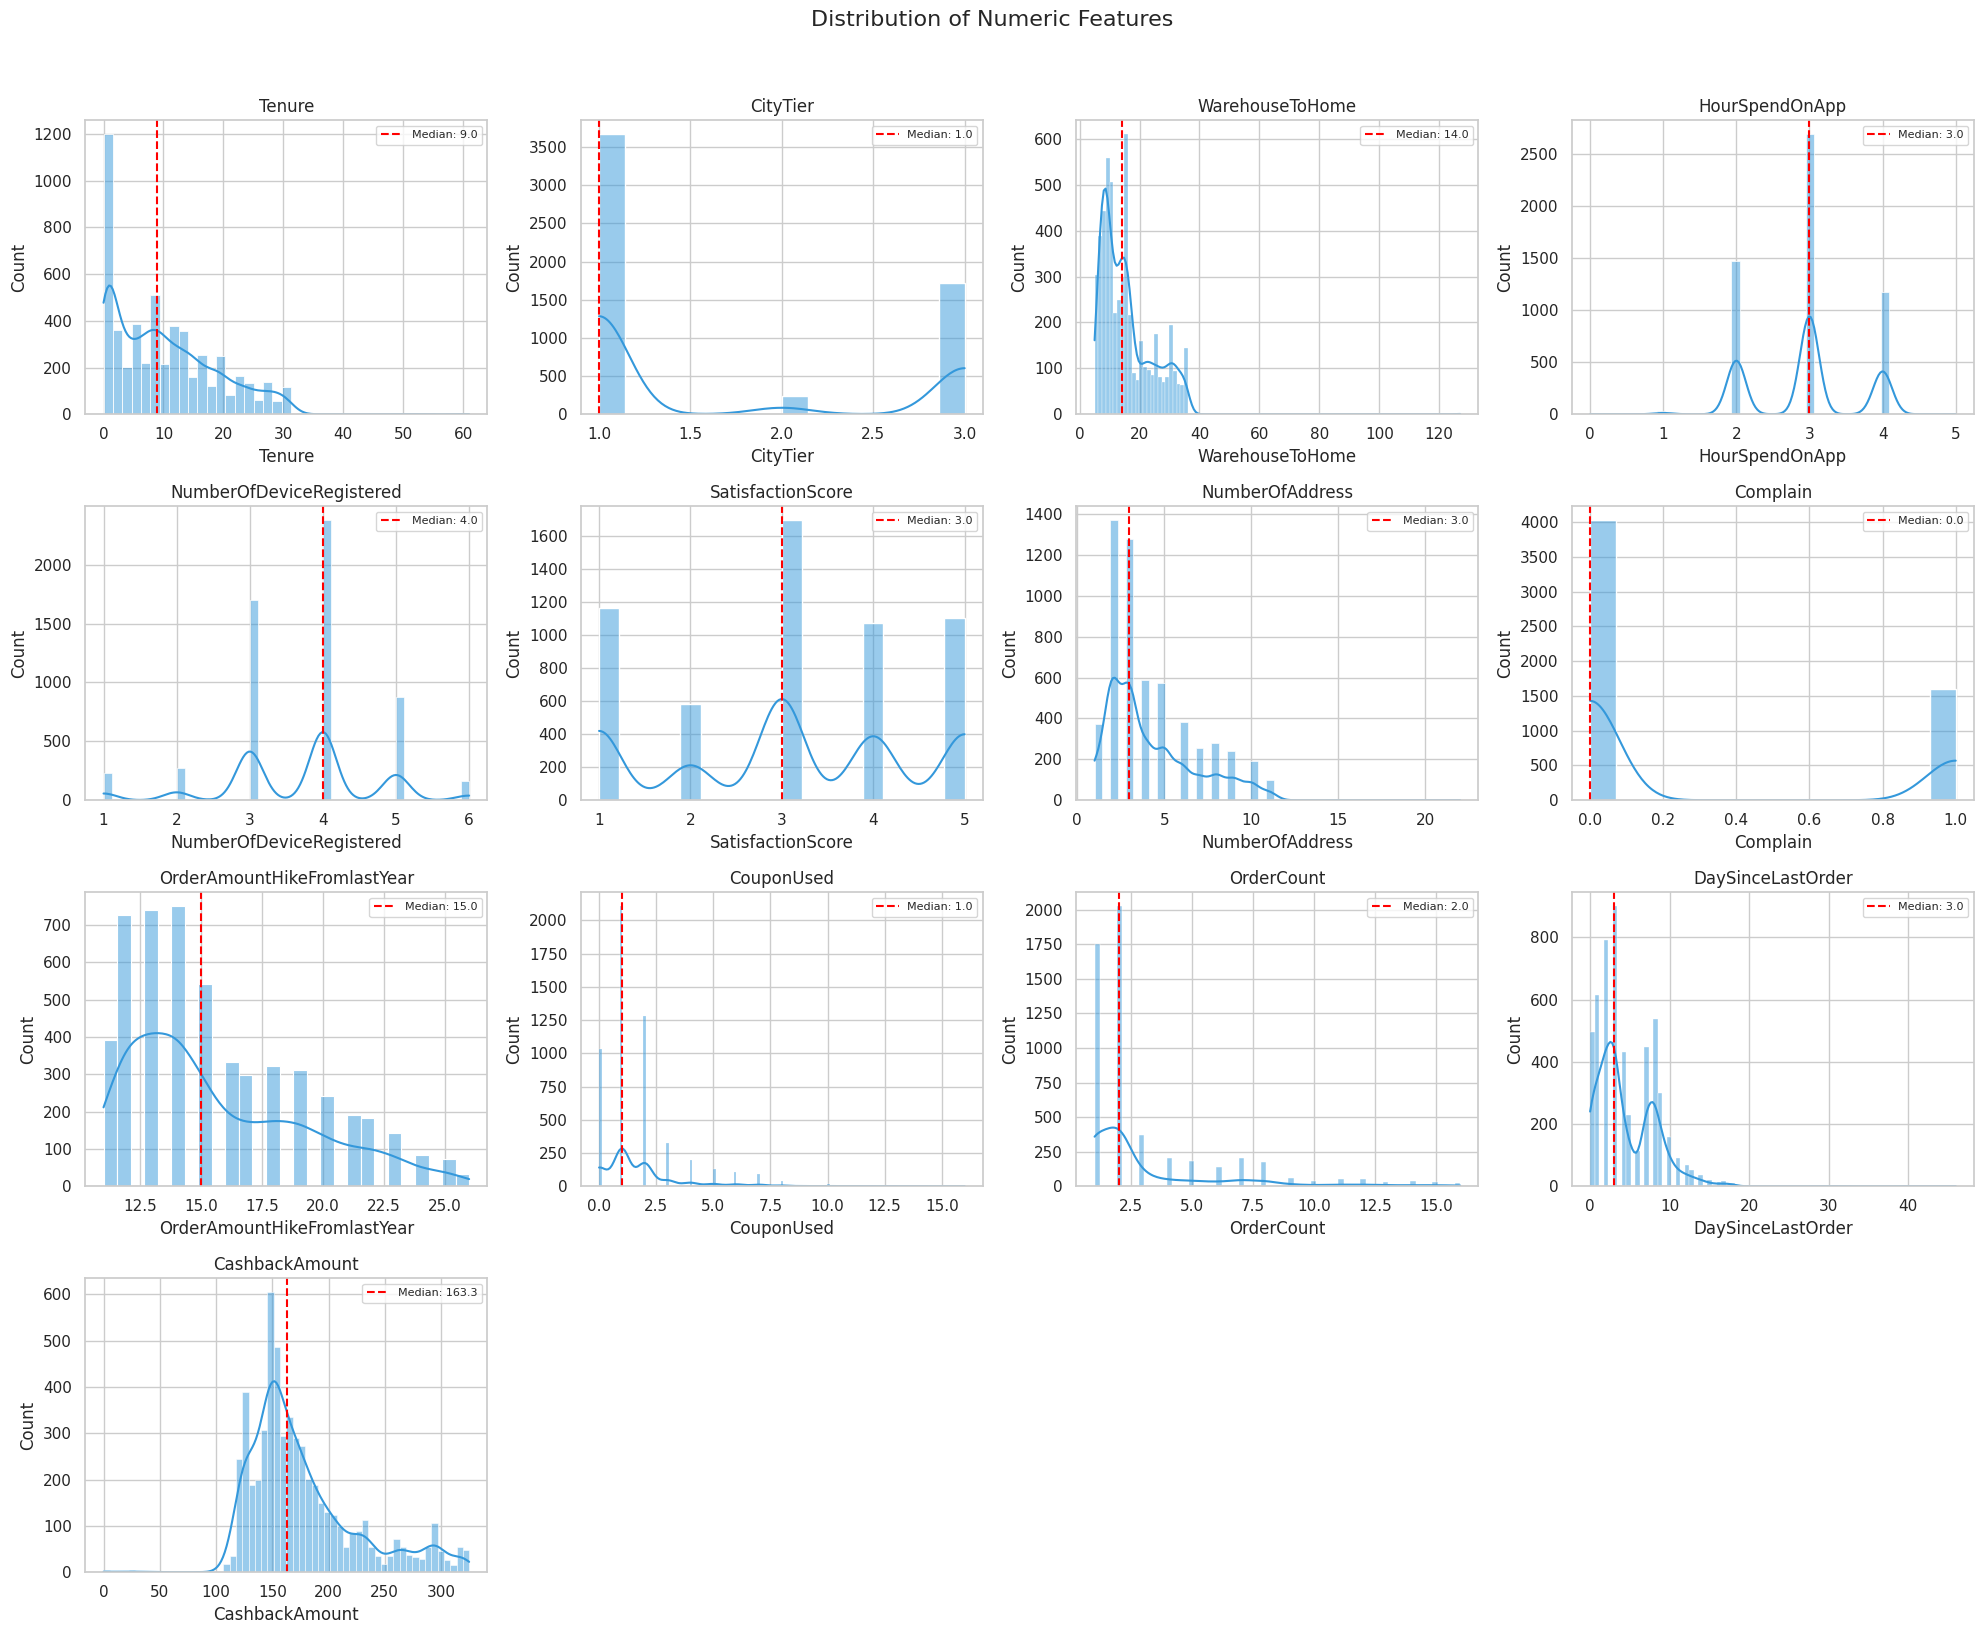

In [10]:
num_cols = df.select_dtypes(include=np.number).columns.drop(["CustomerID", "Churn"]).tolist()
print(f"Numeric features: {len(num_cols)}")

nrows, ncols_grid = 4, 4
fig, axes = plt.subplots(nrows, ncols_grid, figsize=(20, 16))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color="#3498db")
    axes[i].set_title(col)
    axes[i].axvline(df[col].median(), color="red", linestyle="--", label=f"Median: {df[col].median():.1f}")
    axes[i].legend(fontsize=8)

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribution of Numeric Features", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### 5.2 Numeric Features — Box Plots (Outlier Detection)

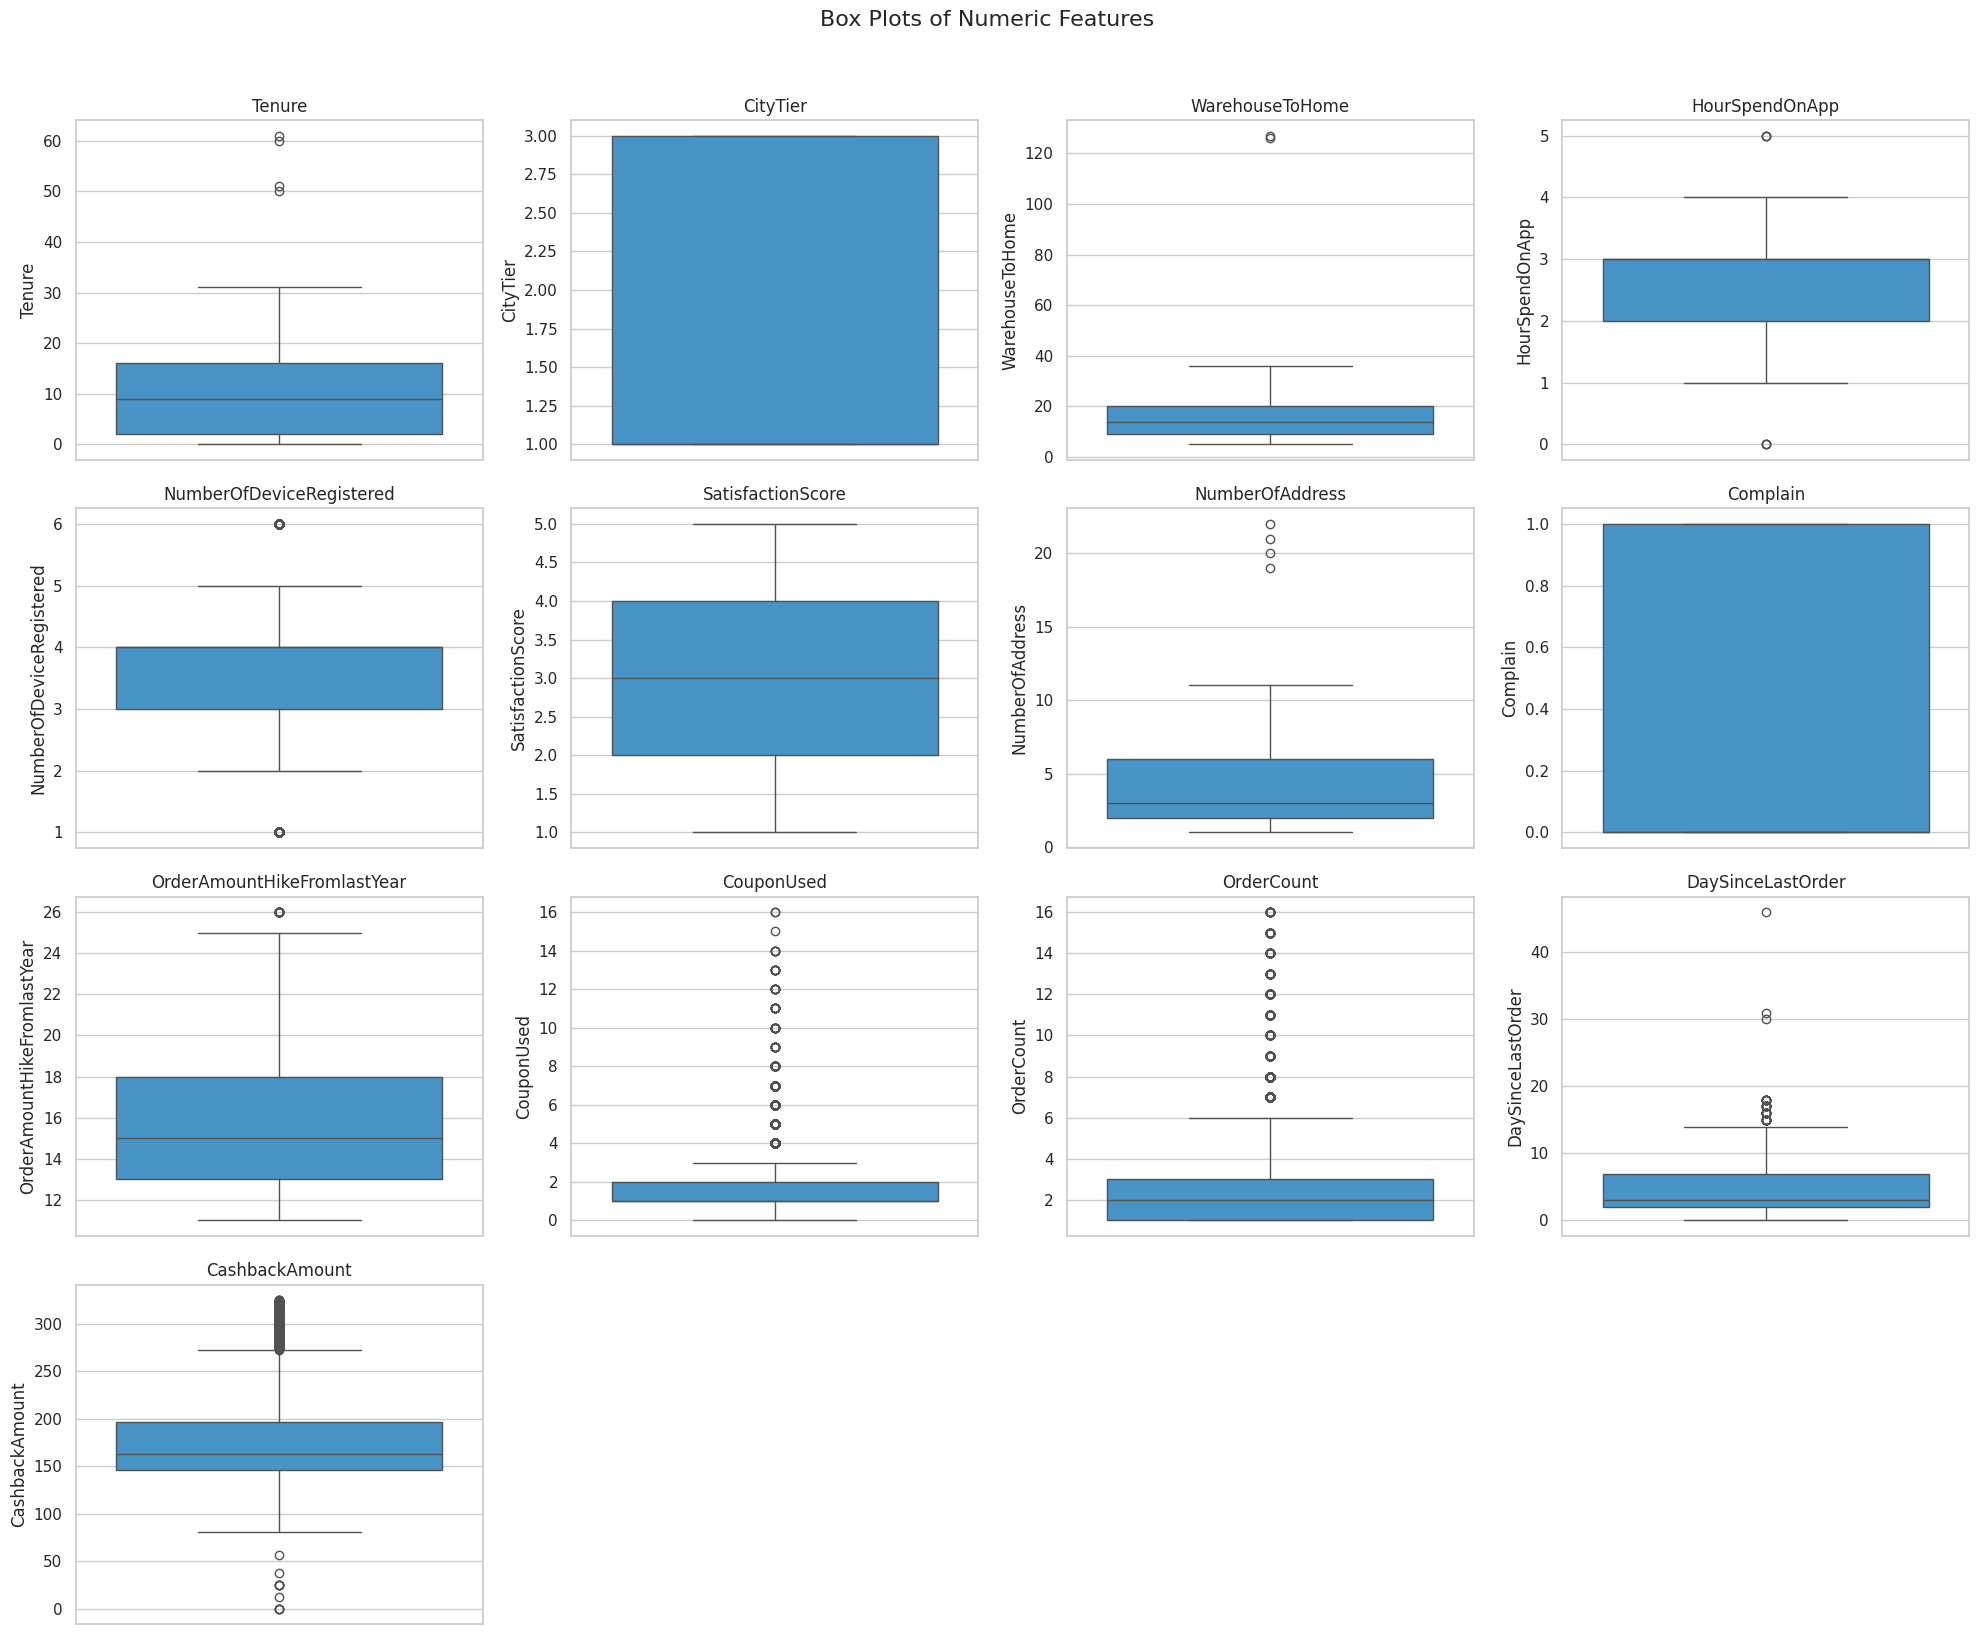

In [11]:
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i], color="#3498db")
    axes[i].set_title(col)

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Box Plots of Numeric Features", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### 5.3 WarehouseToHome — Outlier Investigation

In [12]:
print("WarehouseToHome — Highest values:")
print(df["WarehouseToHome"].nlargest(10).values)
print(f"\nValues >= 100:")
print(df[df["WarehouseToHome"] >= 100]["WarehouseToHome"].value_counts())

WarehouseToHome — Highest values:
[127. 126.  36.  36.  36.  36.  36.  36.  36.  36.]

Values >= 100:
WarehouseToHome
126.0    1
127.0    1
Name: count, dtype: int64


**Finding:** Values 126 and 127 are likely data entry errors (a "1" was prepended). These should be corrected to 26 and 27 during cleaning.

### 5.4 Categorical Features — Count Plots

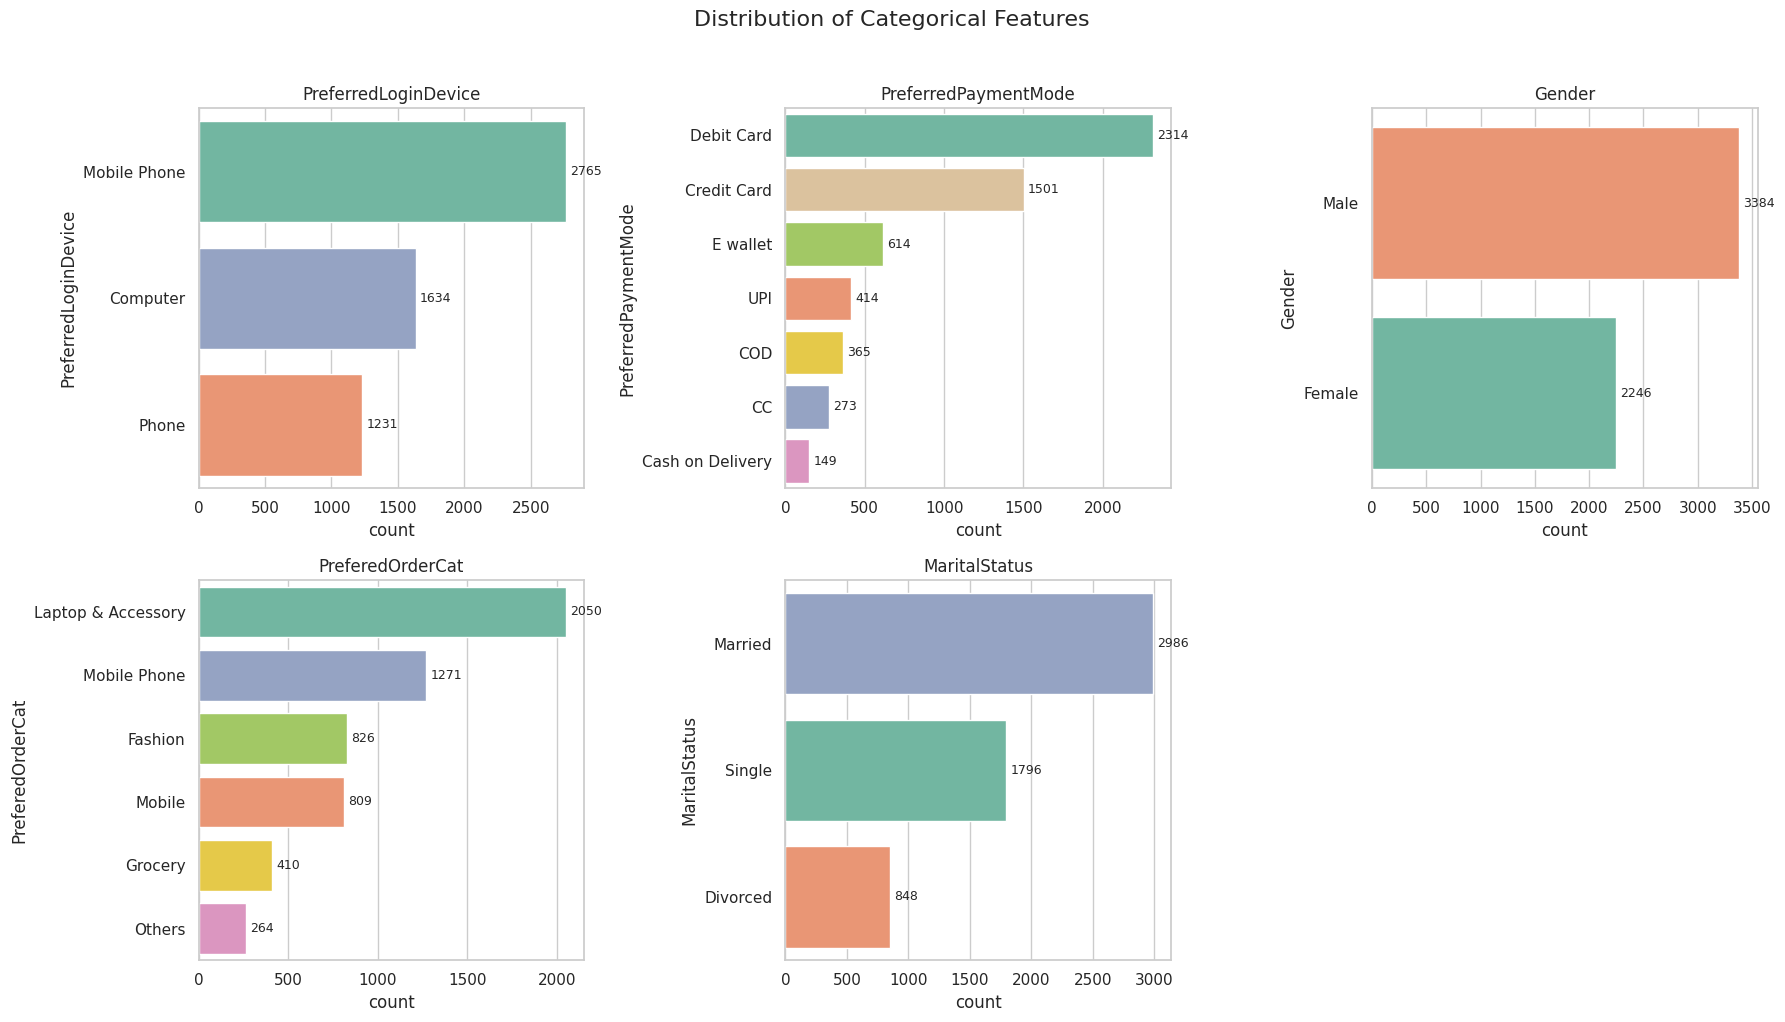

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    order = df[col].value_counts().index
    sns.countplot(y=col, data=df, ax=axes[i], order=order, hue=col, palette="Set2")
    axes[i].set_title(col)
    for container in axes[i].containers:
        axes[i].bar_label(container, fmt="%d", padding=3, fontsize=9)

for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribution of Categorical Features", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 6. Bivariate Analysis — Features vs Churn

### 6.1 Numeric Features vs Churn

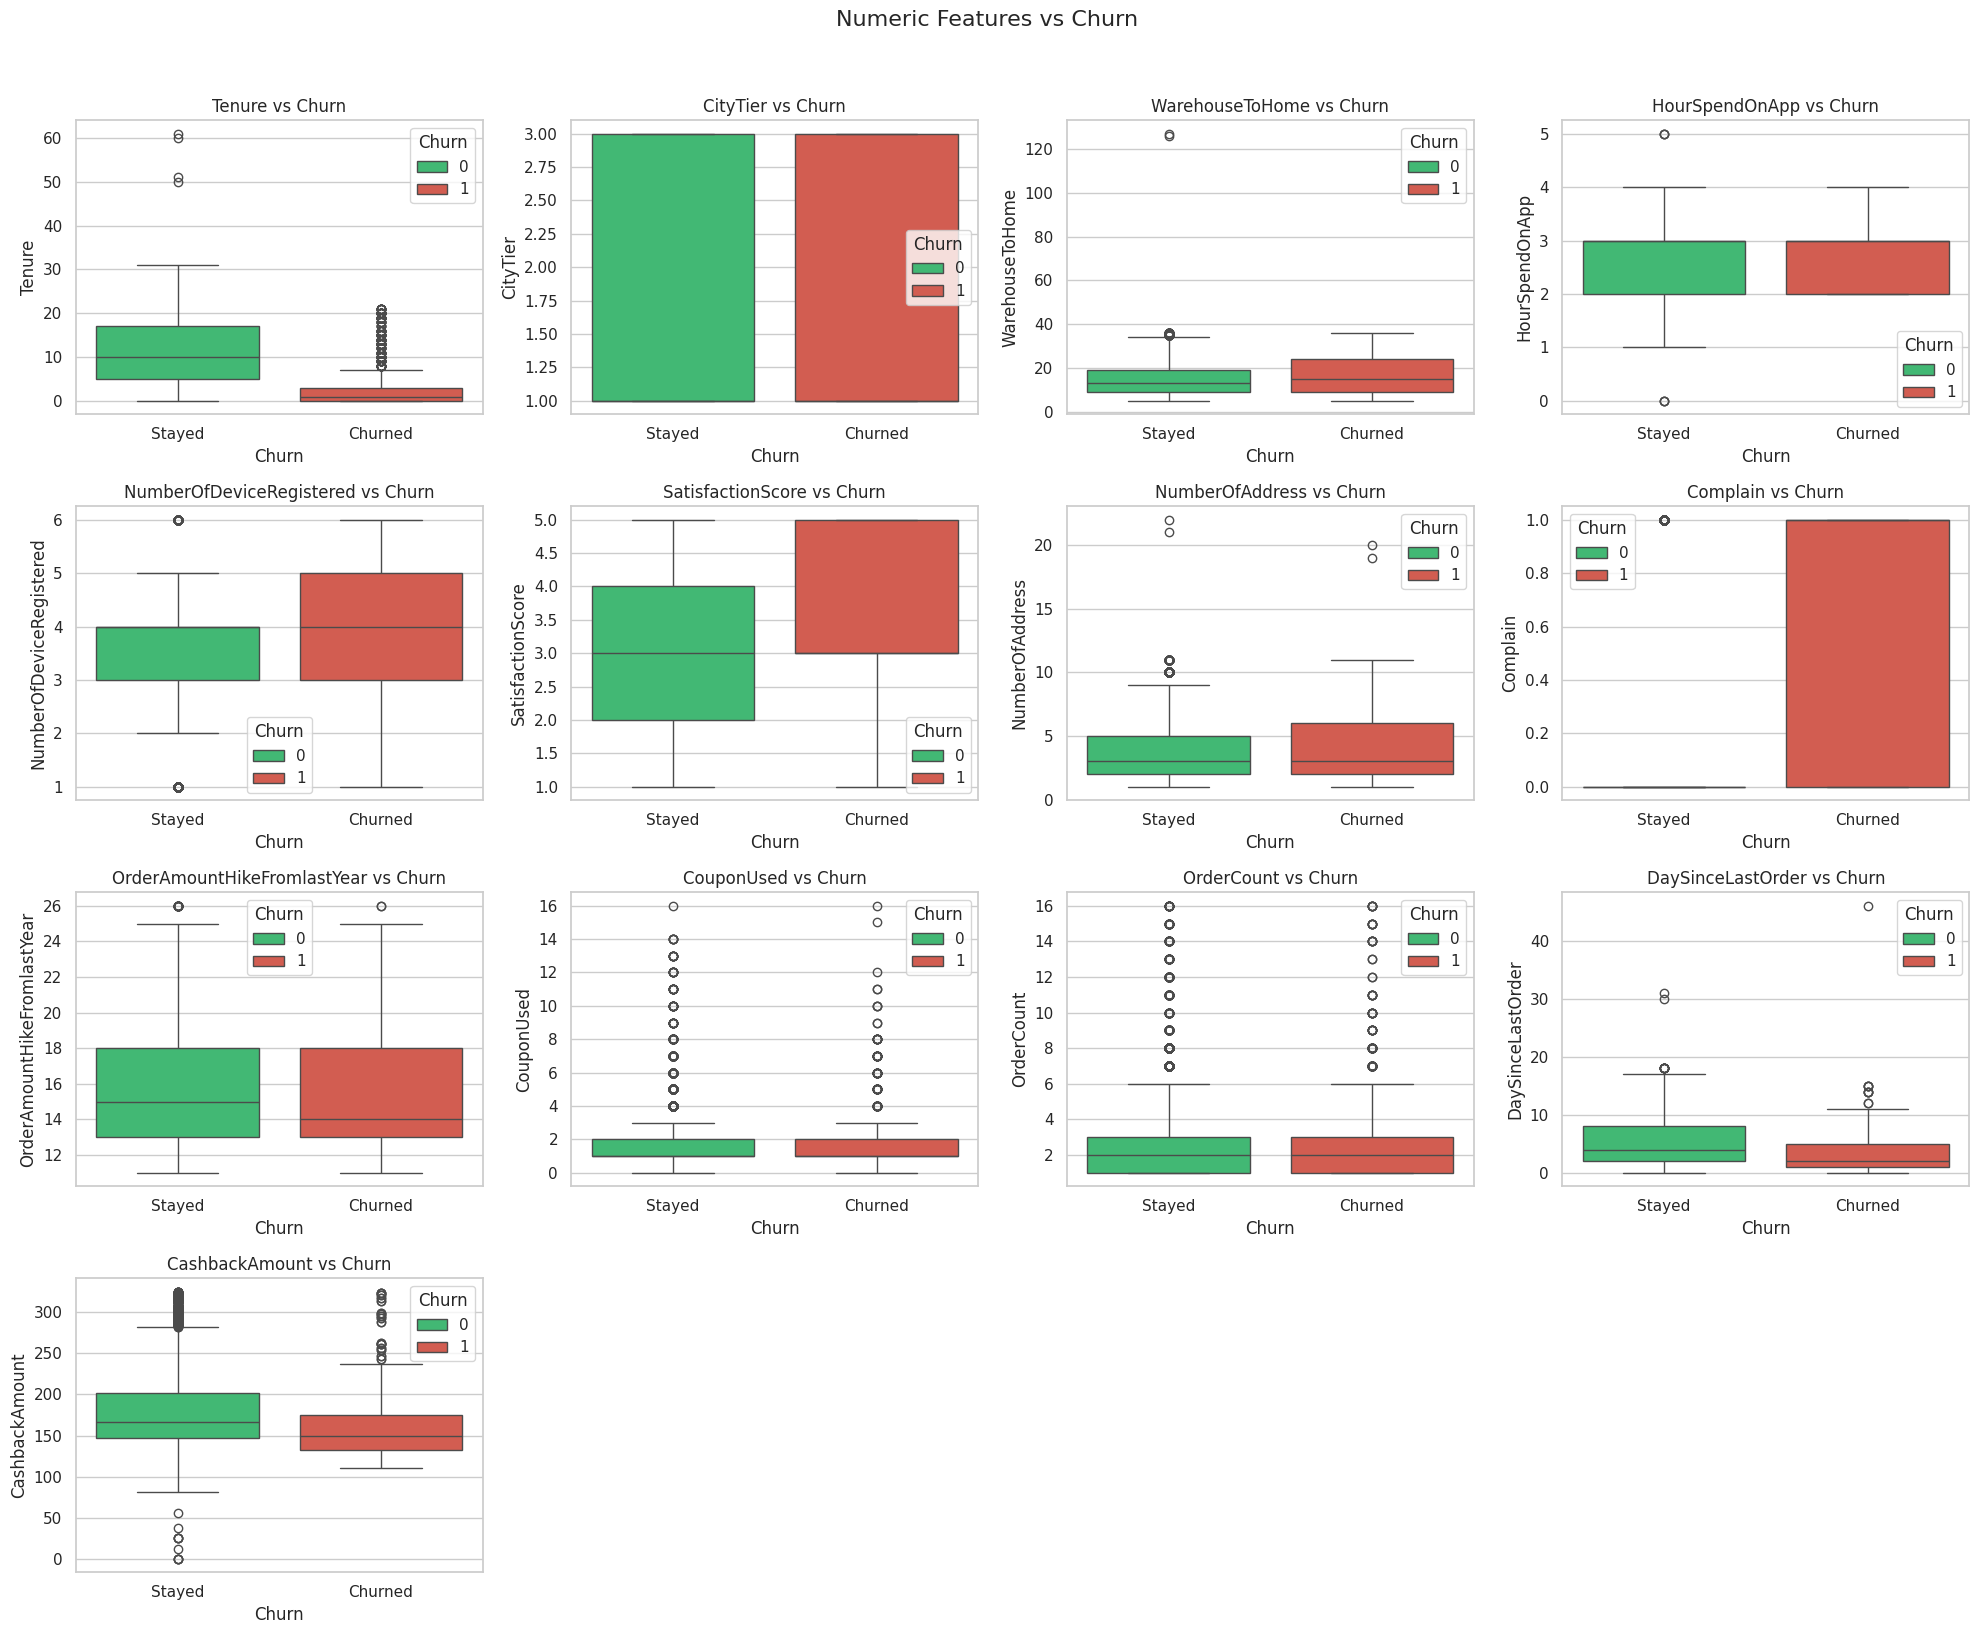

In [14]:
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x="Churn", y=col, data=df, ax=axes[i], hue="Churn",
                palette=["#2ecc71", "#e74c3c"])
    axes[i].set_title(f"{col} vs Churn")
    axes[i].set_xticklabels(["Stayed", "Churned"])

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Numeric Features vs Churn", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### 6.2 Categorical Features vs Churn

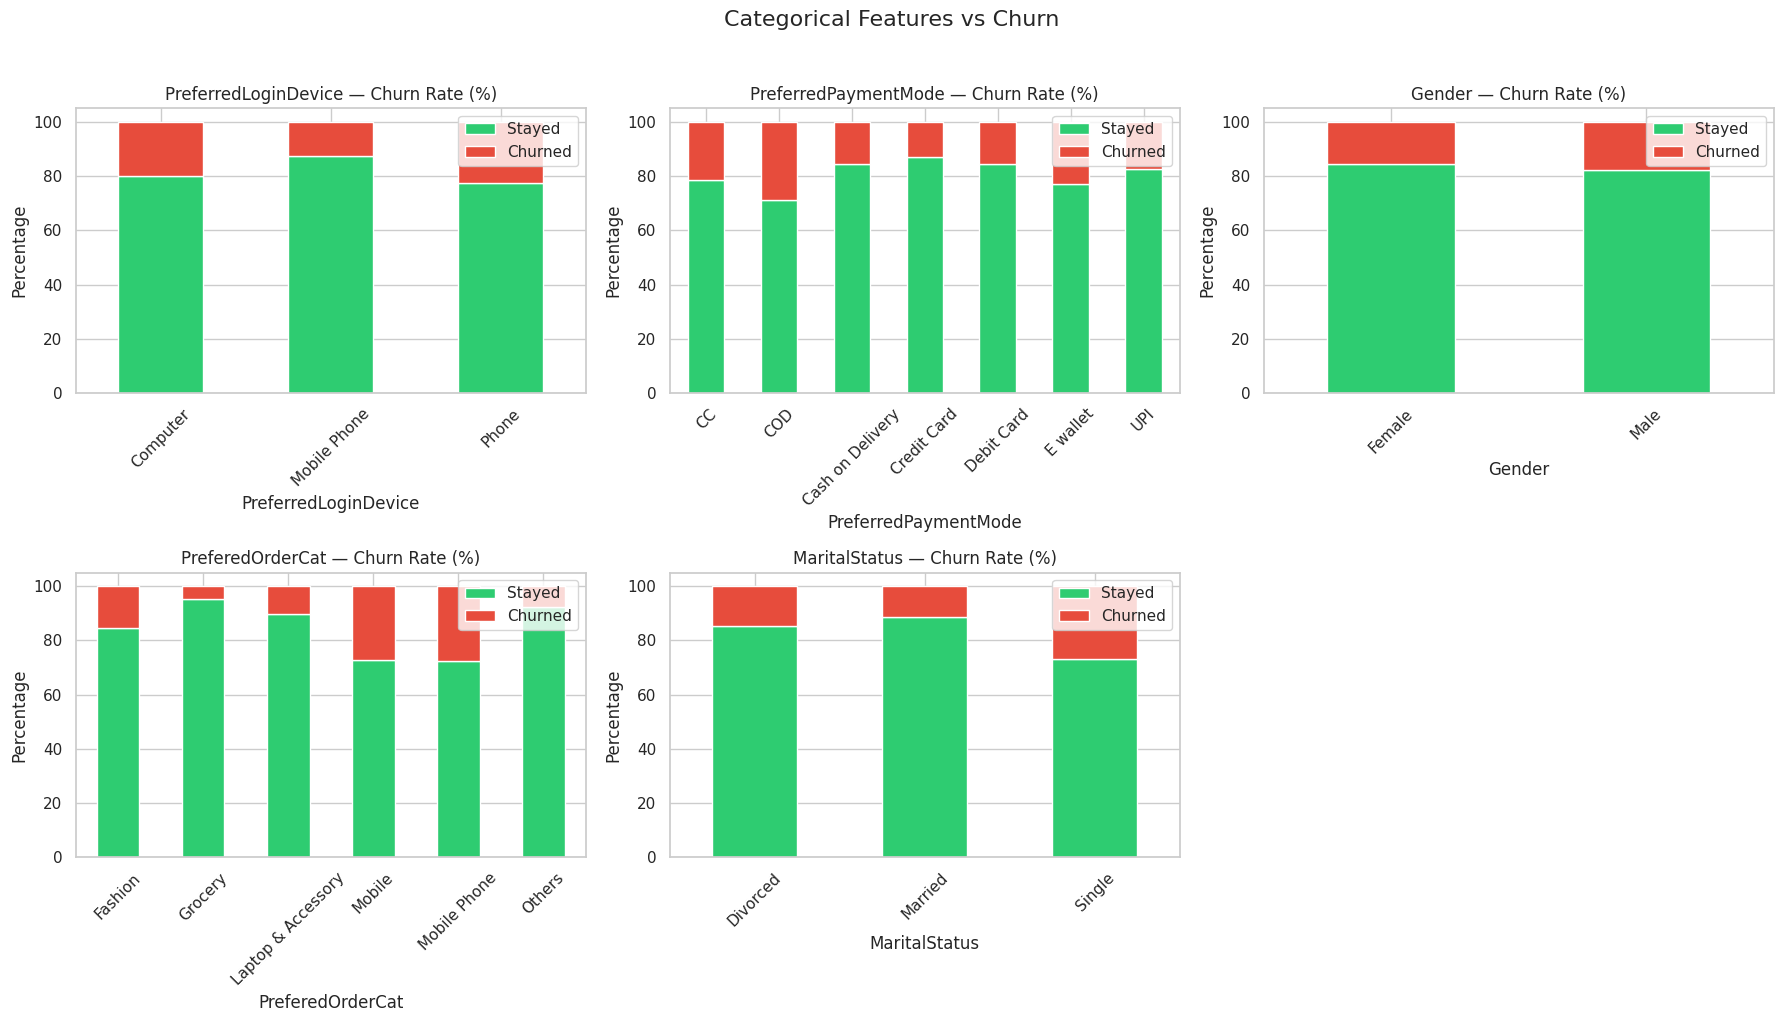

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df["Churn"], normalize="index") * 100
    ct.plot(kind="bar", stacked=True, ax=axes[i], color=["#2ecc71", "#e74c3c"])
    axes[i].set_title(f"{col} — Churn Rate (%)")
    axes[i].set_ylabel("Percentage")
    axes[i].legend(["Stayed", "Churned"], loc="upper right")
    axes[i].tick_params(axis="x", rotation=45)

for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Categorical Features vs Churn", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### 6.3 Complaint vs Churn

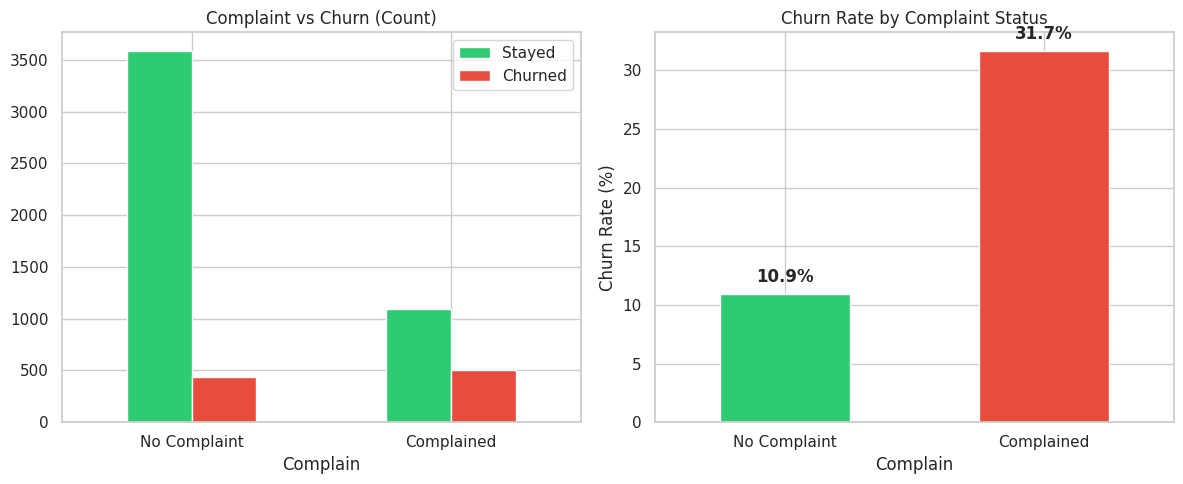

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Complaint count by churn
ct = pd.crosstab(df["Complain"], df["Churn"])
ct.plot(kind="bar", ax=axes[0], color=["#2ecc71", "#e74c3c"])
axes[0].set_title("Complaint vs Churn (Count)")
axes[0].set_xticklabels(["No Complaint", "Complained"], rotation=0)
axes[0].legend(["Stayed", "Churned"])

# Churn rate by complaint
churn_rate = df.groupby("Complain")["Churn"].mean() * 100
churn_rate.plot(kind="bar", ax=axes[1], color=["#2ecc71", "#e74c3c"])
axes[1].set_title("Churn Rate by Complaint Status")
axes[1].set_xticklabels(["No Complaint", "Complained"], rotation=0)
axes[1].set_ylabel("Churn Rate (%)")
for i, v in enumerate(churn_rate.values):
    axes[1].text(i, v + 1, f"{v:.1f}%", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

### 6.4 Satisfaction Score vs Churn by City Tier

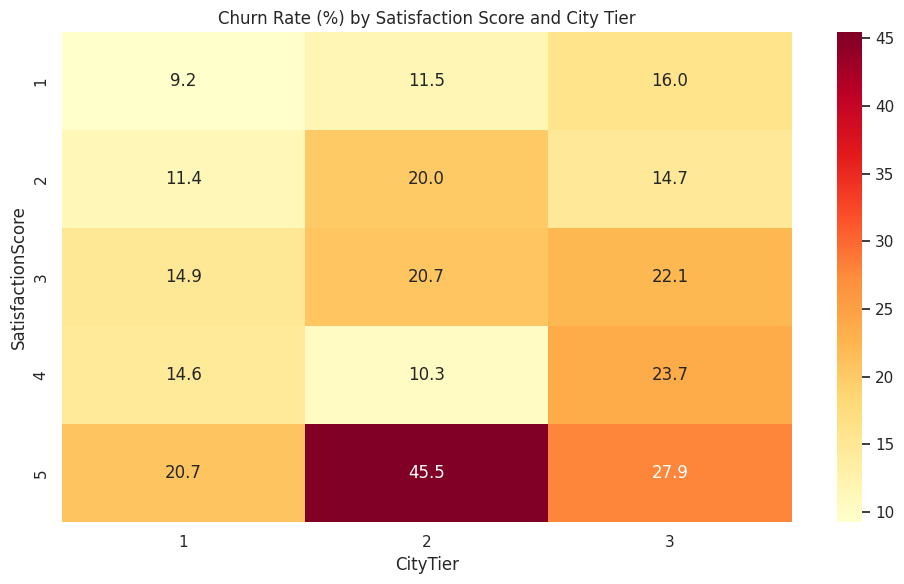

In [17]:
pivot = df.pivot_table(values="Churn", index="SatisfactionScore",
                       columns="CityTier", aggfunc="mean") * 100

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlOrRd", ax=ax)
ax.set_title("Churn Rate (%) by Satisfaction Score and City Tier")
plt.tight_layout()
plt.show()

### 6.5 Tenure vs Churn

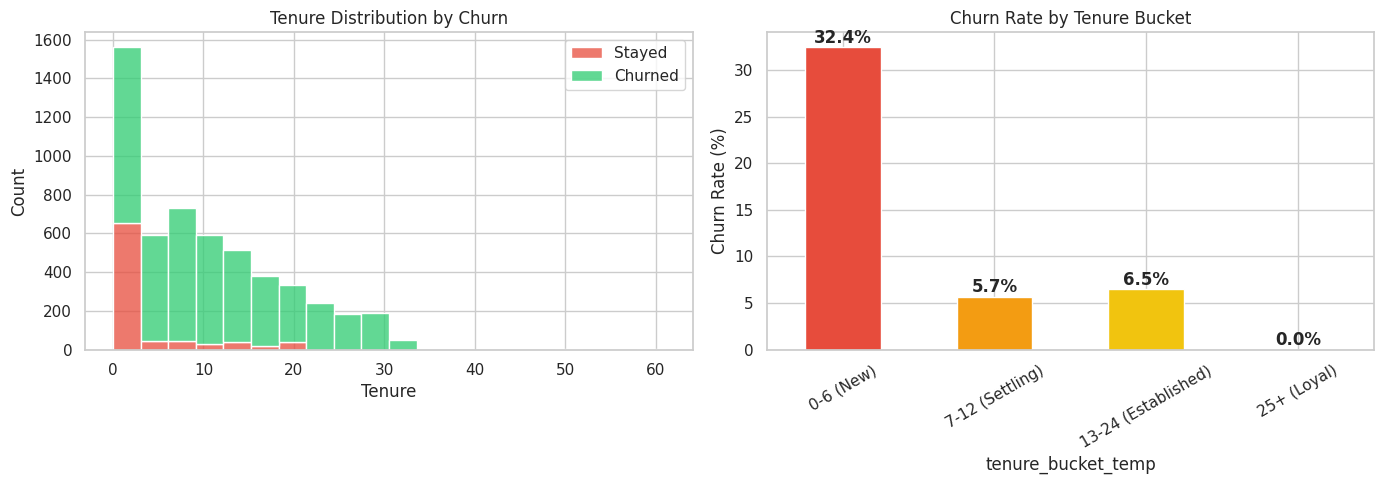

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tenure distribution by churn
sns.histplot(data=df, x="Tenure", hue="Churn", multiple="stack", ax=axes[0],
             palette=["#2ecc71", "#e74c3c"], bins=20)
axes[0].set_title("Tenure Distribution by Churn")
axes[0].legend(["Stayed", "Churned"])

# Churn rate by tenure bucket
bins = [0, 6, 12, 24, 61]
labels = ["0-6 (New)", "7-12 (Settling)", "13-24 (Established)", "25+ (Loyal)"]
df["tenure_bucket_temp"] = pd.cut(df["Tenure"], bins=bins, labels=labels, include_lowest=True)
churn_by_tenure = df.groupby("tenure_bucket_temp", observed=True)["Churn"].mean() * 100
churn_by_tenure.plot(kind="bar", ax=axes[1], color=["#e74c3c", "#f39c12", "#f1c40f", "#2ecc71"])
axes[1].set_title("Churn Rate by Tenure Bucket")
axes[1].set_ylabel("Churn Rate (%)")
axes[1].tick_params(axis="x", rotation=30)
for i, v in enumerate(churn_by_tenure.values):
    axes[1].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontweight="bold")
df.drop(columns="tenure_bucket_temp", inplace=True)

plt.tight_layout()
plt.show()

### 6.6 Cashback & Coupon Usage vs Churn

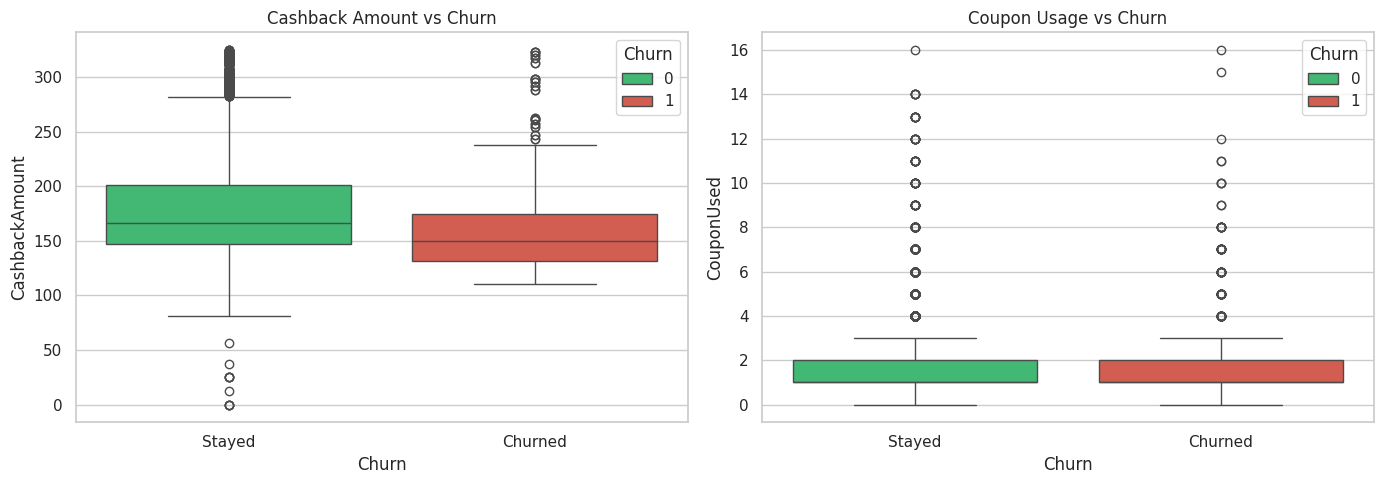

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cashback vs Churn
sns.boxplot(x="Churn", y="CashbackAmount", data=df, ax=axes[0], hue="Churn",
            palette=["#2ecc71", "#e74c3c"])
axes[0].set_title("Cashback Amount vs Churn")
axes[0].set_xticklabels(["Stayed", "Churned"])

# Coupon usage vs Churn
sns.boxplot(x="Churn", y="CouponUsed", data=df, ax=axes[1], hue="Churn",
            palette=["#2ecc71", "#e74c3c"])
axes[1].set_title("Coupon Usage vs Churn")
axes[1].set_xticklabels(["Stayed", "Churned"])

plt.tight_layout()
plt.show()

## 7. Correlation Analysis

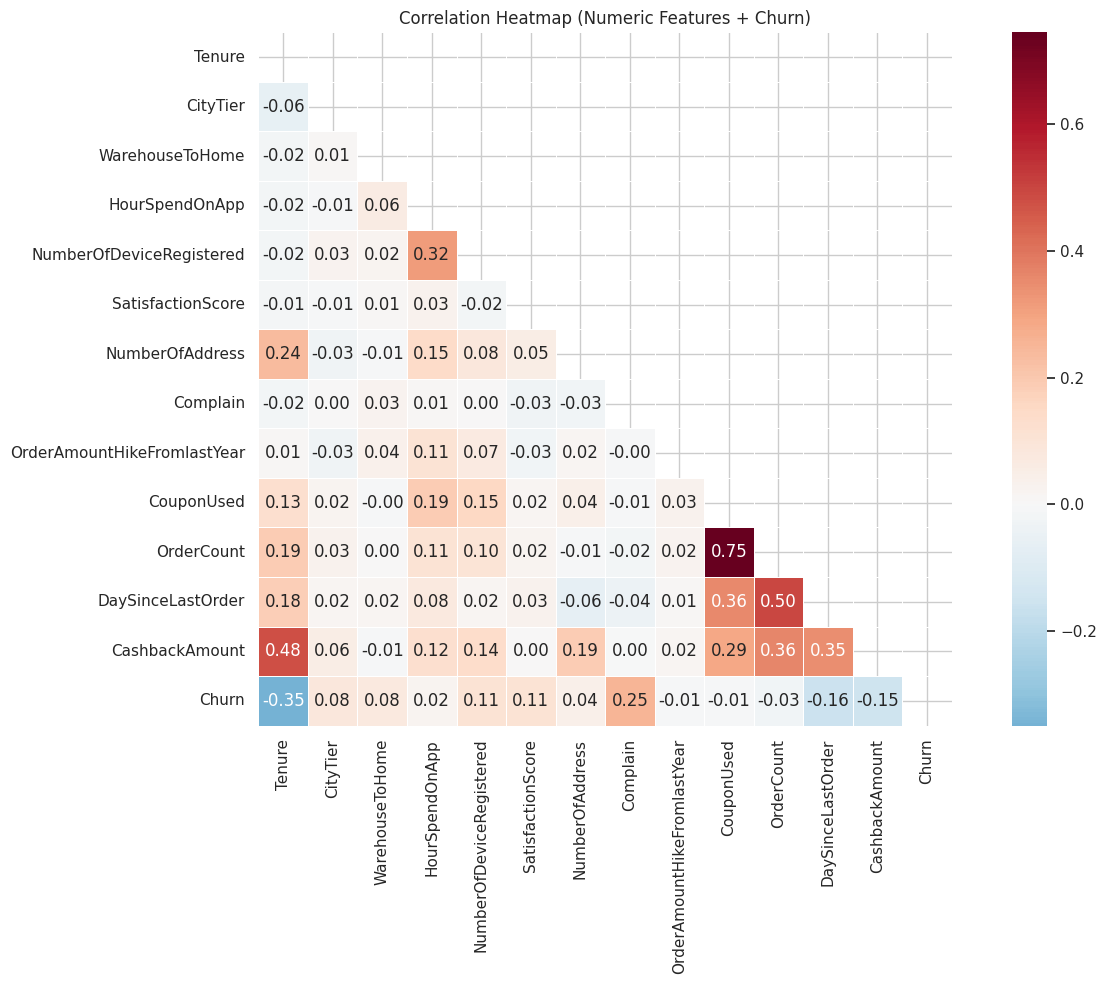

In [20]:
corr_cols = num_cols + ["Churn"]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, ax=ax, square=True, linewidths=0.5)
ax.set_title("Correlation Heatmap (Numeric Features + Churn)")
plt.tight_layout()
plt.show()

In [21]:
# Top correlations with Churn
churn_corr = corr["Churn"].drop("Churn").sort_values(key=abs, ascending=False)
print("Feature correlations with Churn:")
print(churn_corr.to_string())

Feature correlations with Churn:
Tenure                        -0.349408
Complain                       0.250188
DaySinceLastOrder             -0.160757
CashbackAmount                -0.154118
NumberOfDeviceRegistered       0.107939
SatisfactionScore              0.105481
CityTier                       0.084703
WarehouseToHome                0.076630
NumberOfAddress                0.043931
OrderCount                    -0.028697
HourSpendOnApp                 0.018675
OrderAmountHikeFromlastYear   -0.010058
CouponUsed                    -0.008264


## 8. Key Findings Summary

### Data Quality Issues
1. **Missing values:** 7 columns with 4.5-5.5% missing — Tenure, WarehouseToHome, HourSpendOnApp, OrderAmountHikeFromlastYear, CouponUsed, OrderCount, DaySinceLastOrder
2. **Duplicate categories:** Phone/Mobile Phone, CC/Credit Card, COD/Cash on Delivery, Mobile/Mobile Phone
3. **Outliers:** WarehouseToHome has values 126 and 127 (data entry errors — should be 26 and 27)

### Churn Insights
4. **Churn rate:** ~16.84% (moderate class imbalance)
5. **Complaint is a strong predictor:** Customers who complained have significantly higher churn rate
6. **Tenure matters:** New customers (0-6 months) churn at much higher rates than loyal customers (25+ months)
7. **Satisfaction Score:** Surprisingly, satisfaction alone doesn't show a clear linear relationship with churn — context (city tier) matters
8. **Cashback & Coupons:** Higher coupon usage correlates with higher churn (possibly deal-seekers with low loyalty)

<!-- ### Next Steps
- **Data Cleaning:** Fix duplicate categories, outliers, impute missing values (median) → `src/data_cleaning.py`
- **Feature Engineering:** Create tenure_bucket, engagement_score, cashback_per_order, etc. → `src/feature_engineering.py`
- **Modeling:** Address class imbalance with SMOTE, use F1/AUC-PR as primary metrics -->